# Домашнее задание 2. Линейные модели и регуляризация

В этом домашнем задании вы будете работать с набором данных по добыче газа: необходимо оценить, сколько денег будет приносить каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа.
Ваша задача — пройти полный базовый цикл построения модели: от анализа и предобработки данных до обучения и улучшения линейной регрессии.

Итоговая цель — построить интерпретируемую и устойчивую модель, предсказывающую суточную добычу газа на основе геологических характеристик скважины.

**Описание признаков**

| Признак                | Описание                        |
| ---------------------- | ------------------------------- |
| `well_id`              | идентификатор скважины          |
| `porosity`             | пористость скважины             |
| `permeability`         | проницаемость скважины          |
| `acoustic_impedance`   | акустический импеданс           |
| `brittleness`          | коэффициент хрупкости скважины  |
| `organic_carbon`       | общий органический углерод      |
| `vitrinite_reflectance`| коэффициент отражения витринита |

**Целевая переменная**

`extr_per_day` — добыча газа в сутки (млн кубических футов).


In [ ]:
# Импорт нужных библиотек и моделей,
# Добавляйте в ячейку все, что потребуется

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from typing import Optional, List, Tuple, Union

### Задание 1
Первым делом **познакомимся с данными**, а заодно закрепим методы работы с Pandas.

0. Прочитайте файл, посмотрите на семпл и количество строк.
1. Проверьте наличие пропусков в данных и при необходимости обработайте их.  
2. Проверьте наличие выбросов  и ошибочных значений (тут полезно обратиться к смыслу признаков) и при необходимости почистите их.
3. Проверьте наличие дубликатов и при необходимости почистите их.
4. Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
5. Запишите наблюдения в виде небольшого вывода.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ivanchiginev3/MIPT-Machine-Learning-Homeworks/refs/heads/main/HW_2/well_data.csv')
df.head()

,well_id,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                200 non-null    int64  
 1   porosity               200 non-null    float64
 2   permeability           200 non-null    float64
 3   acoustic_impedance     200 non-null    float64
 4   brittleness            200 non-null    float64
 5   organic_carbon         200 non-null    float64
 6   vitrinite_reflectance  200 non-null    float64
 7   extr_per_day           200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [ ]:
df.describe()

,well_id,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,57.879185,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,1.000000,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,50.750000,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,100.500000,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,150.250000,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,200.000000,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop('well_id', axis=1)

**Вывод:**
1. Пропусков в данных нет  
2. На первый взгляд выбросов и ошибочных значений нет
3. Дубликатов нет
4. Один неиформативный признак это - `well_id`

## Задание 2

Проведем небольшой **EDA.**

1. Посмотрите на распределение целевого признака `extr_per_day`.
2. Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot` либо построить графики по отдельности).
3. Постройте матрицу корреляций, визуализируйте ее и проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7).
4. Зафиксируйте наблюдения в небольшом выводе.

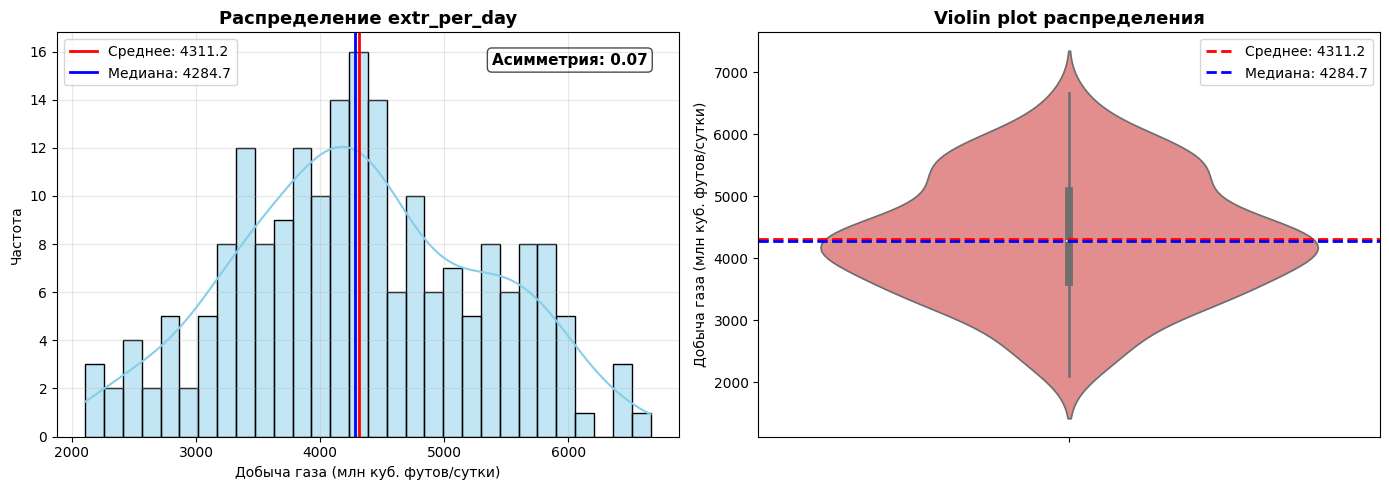

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['extr_per_day'], bins=30, kde=True, ax=ax1, color='skyblue', edgecolor='black')
ax1.axvline(df['extr_per_day'].mean(), color='red', linewidth=2, label=f'Среднее: {df['extr_per_day'].mean():.1f}')
ax1.axvline(df['extr_per_day'].median(), color='blue', linewidth=2, label=f'Медиана: {df['extr_per_day'].median():.1f}')
ax1.set_title('Распределение extr_per_day', fontsize=13, fontweight='bold')
ax1.set_xlabel('Добыча газа (млн куб. футов/сутки)')
ax1.set_ylabel('Частота')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.95, 0.95, f'Асимметрия: {df['extr_per_day'].skew():.2f}',
         transform=ax1.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='None', alpha=0.7))

sns.violinplot(y=df['extr_per_day'], ax=ax2, color='lightcoral', inner='box')
ax2.axhline(df['extr_per_day'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df['extr_per_day'].mean():.1f}')
ax2.axhline(df['extr_per_day'].median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: {df['extr_per_day'].median():.1f}')
ax2.set_title('Violin plot распределения', fontsize=13, fontweight='bold')
ax2.set_ylabel('Добыча газа (млн куб. футов/сутки)')
ax2.legend()

plt.tight_layout()
plt.show()

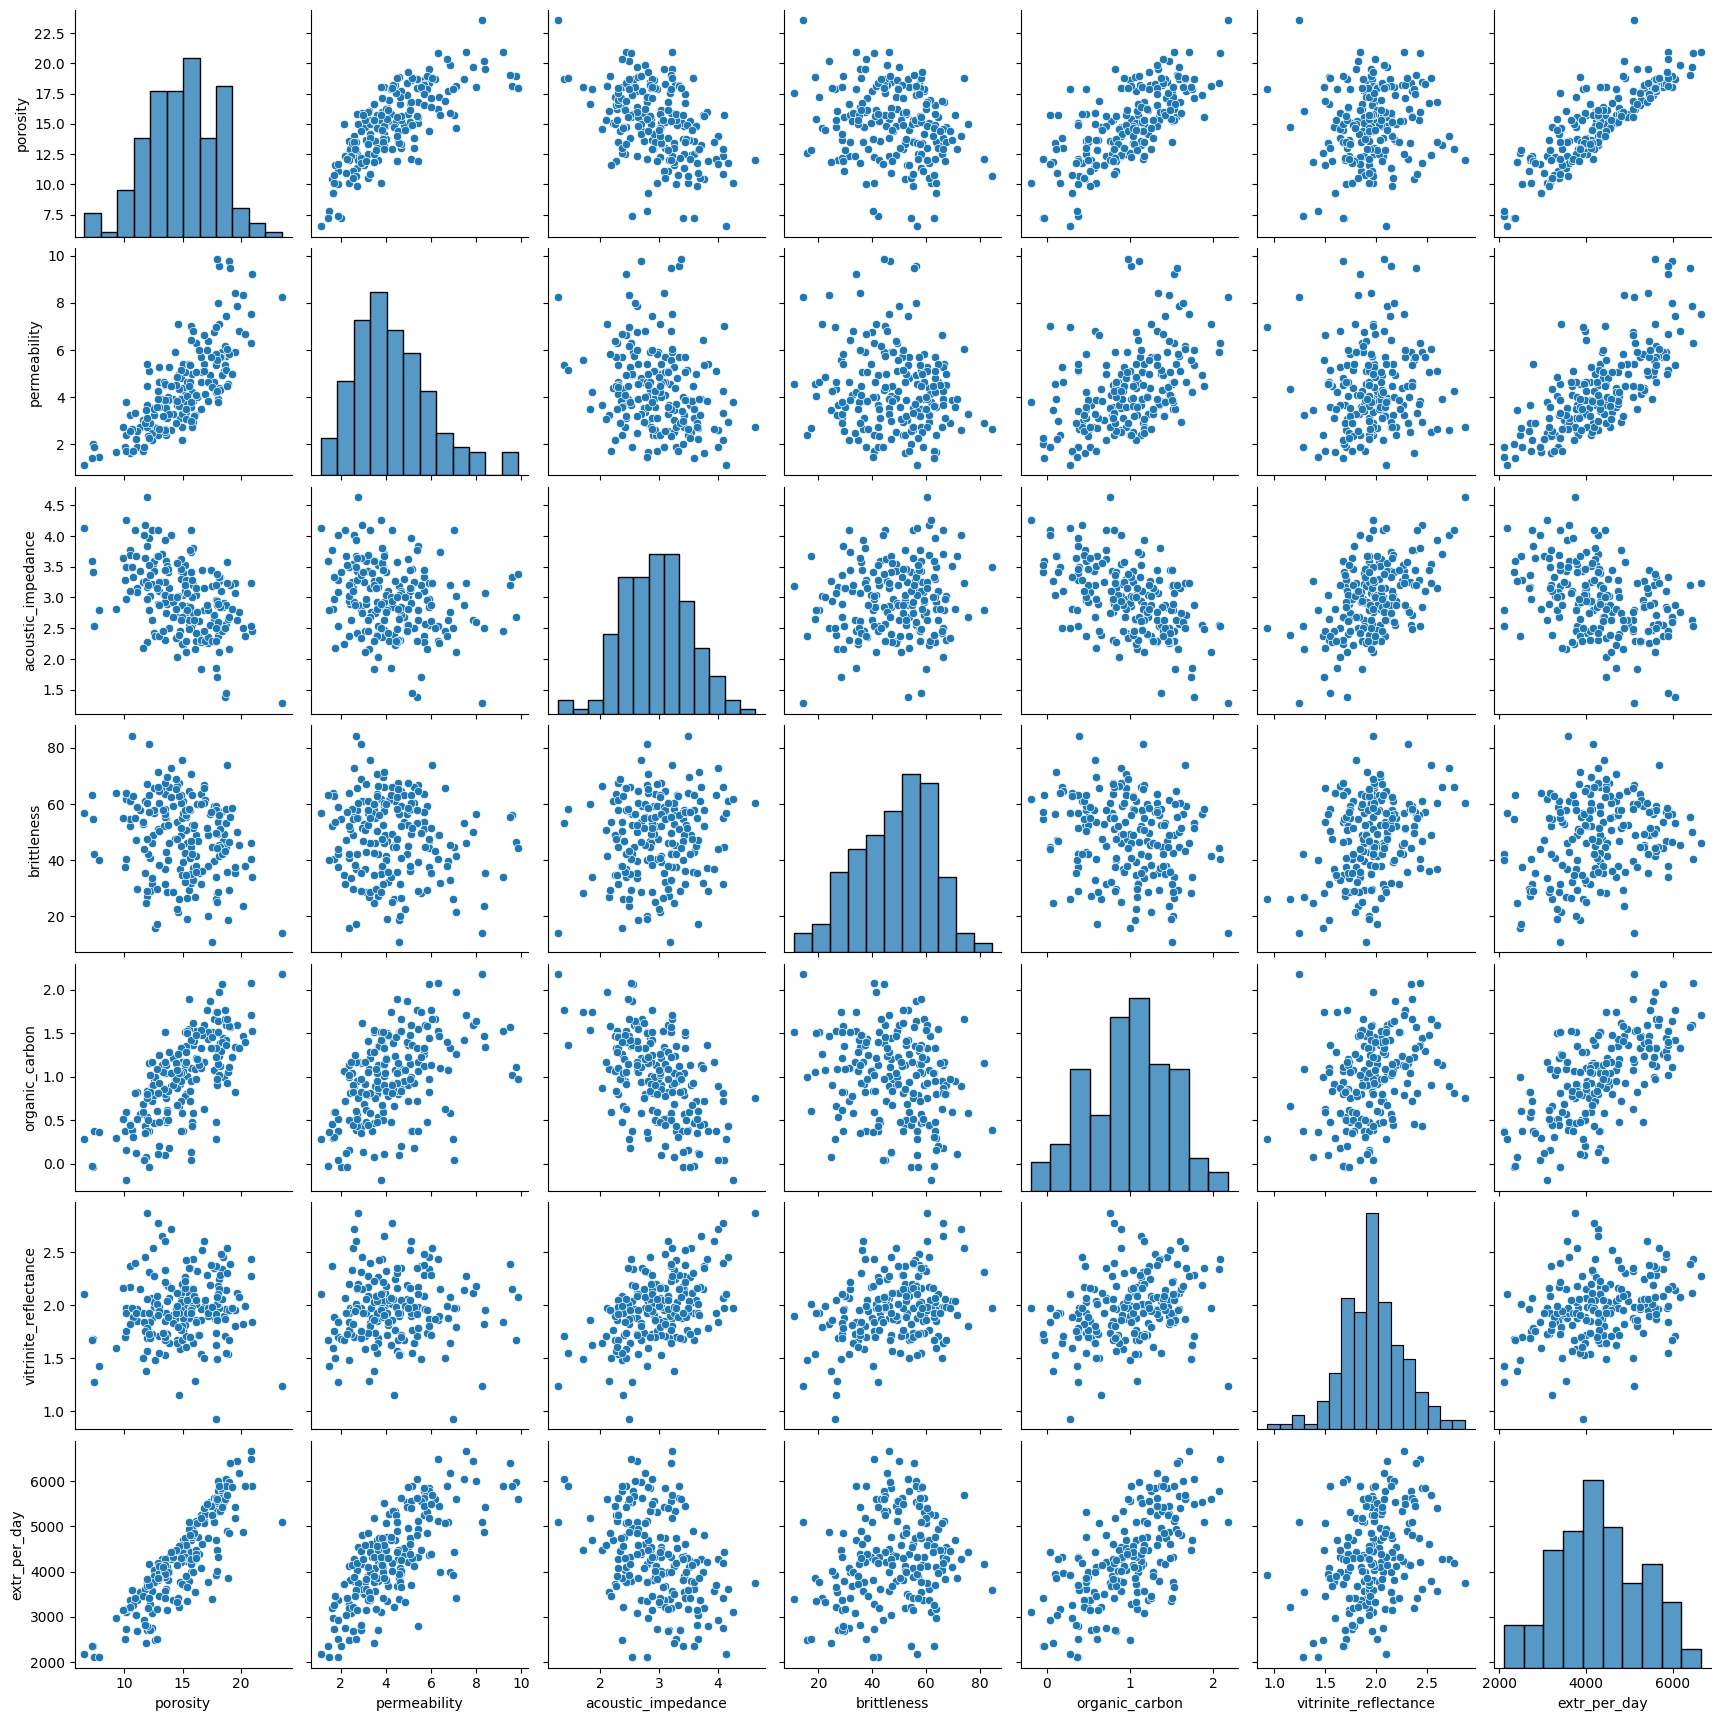

In [ ]:
sns.pairplot(df, diag_kind='hist')
plt.show()

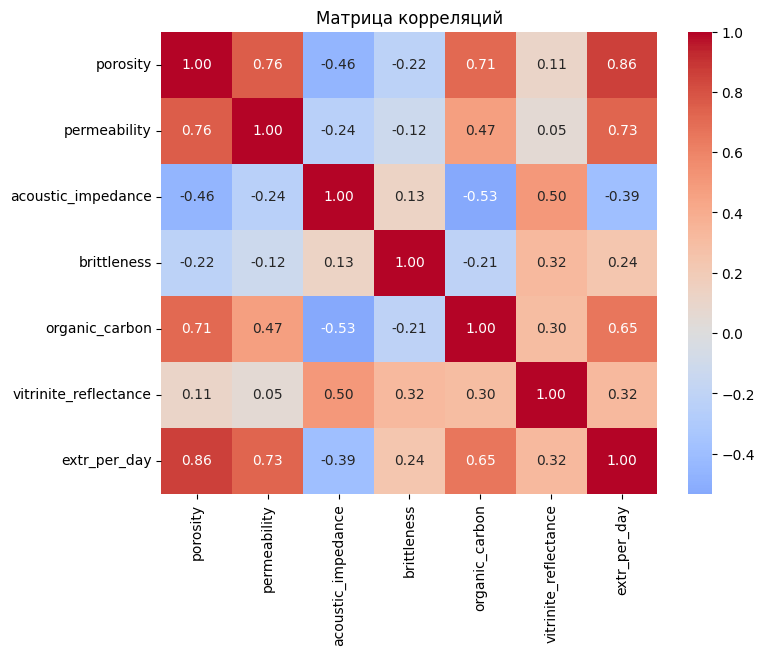

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Матрица корреляций")
plt.show()

**Вывод:** В ходе анализа выявлены две пары признаков с корреляцией выше порога 0.7:
Изначально было принято решение удалить два признака: `permeability` и `organic_carbon`, однако на следующих этапах анализа метрик моделей были протестированы варианты удаления только `permeability` и только `organic_carbon`. По результатам анализа оказалось, что удаление `organic_carbon` дает наилучшие результаты. Это свидетельствует о том, что, несмотря на высокую корреляцию, `permeability` содержит дополнительную полезную информацию, тогда как `organic_carbon` создает избыточность, ухудшающую качество прогноза. Таким образом далее удалим признак `organic_carbon`


## Задание 3

**Финально подготовим данные для модели.**

* По итогам EDA удалите сильно скоррелированные признаки, если они нашлись.
* Создайте матрицу признаков `X` и вектор таргета `y`.
* Разбейте данные на тренировочную и тестовую выборку, установите соотношение 80/20 и random_state=42.
* Выберите подходящий способ масштабирования или нормализации данных, примените его для обеих выборок. Также на этом этапе добавьте единичный столбец для вручную применяемых алгоритмов.
* Зафиксируйте все преобразования и обоснования в небольшом выводе.

In [ ]:
df_new = df.drop('organic_carbon', axis=1)

In [ ]:
X = df_new.drop('extr_per_day', axis=1)
y = df_new['extr_per_day']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # разделение на train и test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Вывод:** На основе анализа мультиколлинеарности удален признак `permeability`. Итоговый набор признаков: 5 переменных.

Данные разделены на train/test (80/20, random_state=42), применен StandardScaler (для приведения признаков к единому масштабу, что необходимо для корректной работы градиентного спуска).

Единичный столбец будет добавлен ниже внутри класса `LinearRegressionOLS`

## Задание 4

**Приступаем к моделированию:**

* Первым делом предлагаем построить модель линейной регрессии по МНК: запишите формулу аналитического решения **в текстовой ячейке**, а затем реализуйте ее на Python и сравните результат с `LinearRegression` из `sklearn`.
* Оцените модель по метрикам $MSE$, $MAE$, $MAPE$ и $R^2$ на тренировочной и тестовой выборках. Проанализируйте полученные значения. Насколько модель хорошо предсказывает результат?
* Посмотрите на коэффициенты модели. Можно на основе этого сделать вывод о том, какие признаки наиболее важны при прогнозировании? Соотнесите коэффициенты и названия признаков. Есть ли связь с рассмотренными ранее коэффициентами корреляции?
* Напишите небольшой вывод касательно полученных результатов.

*Базовая формула:*

$$
x = (A^T A)^{-1} A^T b.
$$

In [ ]:
class LinearRegressionOLS:
    """
    Решение линейной регрессии методом наименьших квадратов:
    w = (X^T X)^{-1} X^T y

    Параметры
    ----------
    нет гиперпараметров

    Атрибуты
    ----------
    w_ : np.ndarray или None
        Веса модели (коэффициенты) после обучения
    """
    def __init__(self) -> None:
        self.w_ = None

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет единичный столбец слева"""
        return np.c_[np.ones(X.shape[0]), X]

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionOLS':
        """
        Обучение модели методом наименьших квадратов

        Параметры
        ----------
        X : np.ndarray, форма (n_samples, n_features)
            Матрица признаков (должна включать столбец единиц для свободного члена)
        y : np.ndarray, форма (n_samples,)
            Вектор целевых значений

        Возвращает
        ----------
        self : object
            Возвращает сам экземпляр класса

        Raises
        ------
        ValueError
            Если матрица X^T X вырождена
        """
        try:
            X_with_bias = self._add_intercept(X)
            self.w_ = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
            return self
        except:
            raise ValueError('Матрица X^T X вырождена')

    def predict(self, X):
        """
        Предсказание для новых данных

        Параметры
        ----------
        X : np.ndarray, форма (n_samples, n_features)
            Матрица признаков для предсказания

        Возвращает
        ----------
        y_pred : np.ndarray, форма (n_samples,)
            Предсказанные значения

        Raises
        ------
        RuntimeError
            Если модель не обучена (fit не вызывался)
        ValueError
            Если размерность X не соответствует обученной модели
        """
        if self.w_ is not None:
            X_with_bias = self._add_intercept(X)
            return X_with_bias @ self.w_
        else:
            raise RuntimeError("Модель не обучена. Сначала вызовите fit()")

In [ ]:
model = LinearRegressionOLS()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"R²: {r2:.4f}")
print(f"Bias модели: {model.w_[0]}, веса модели: {model.w_[1:]}")

MSE: 41856.2336
MAE: 144.9424
MAPE: 0.0335
R²: 0.9505
Bias модели: 4330.32511519375, веса модели: [ 685.13682753  199.86665313 -176.55317967  355.54813827  195.02136195]


In [ ]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
y_pred = reg.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"R²: {r2:.4f}")
print(f"Bias модели: {reg.intercept_}, веса модели: {reg.coef_}")

MSE: 41856.2336
MAE: 144.9424
MAPE: 0.0335
R²: 0.9505
Bias модели: 4330.32511519375, веса модели: [ 685.13682753  199.86665313 -176.55317967  355.54813827  195.02136195]


**Вывод:** Собственная реализация МНК и `LinearRegression` из `sklearn` показали идентичные результаты, что подтверждает корректность вычислений.

Качество модели: R² = 0.95, MAPE = 3.3%. Модель объясняет 95% дисперсии целевой переменной, средняя ошибка прогноза составляет менее 5%.

Анализ коэффициентов: Наиболее важный признак — `porosity` (685.1), что согласуется с корреляционным анализом (0.86). Знаки коэффициентов соответствуют направлениям корреляционных связей.

Итог: Модель линейной регрессии успешно построена, показывает высокую точность и может использоваться для прогнозирования добычи газа.

## Задание 5

**Попробуем усложнить:**

* Обучите классический градиентный спуск на подготовленных данных, реализованный вручную. Попробуйте подобрать такие гиперпараметры (шаг, количество итераций), чтобы решение максимально точно совпадало с МНК.
* Модифицируйте классический градиентный спуск, обновляя градиент не по всем обучающим примерам, а только по **случайной подвыборке (мини-батче)**. Сравните алгоритмы по качеству и скорости работы.
* Постройте для каждого эксперимента график сходимости на тренировочной и тестовой выборках и оцените модель по тем же метрикам.
* Напишите небольшой вывод. Удалось ли улучшить прогноз и возможно ли достигнуть более высокого качества, чем у МНК? В каких ситуациях что выбрать: классический градиентный спуск или мини-батчевый?

---

> Справка по градиентным методам:

* $\theta$ — вектор параметров модели
* $\eta$ — шаг обучения (learning rate)
* $\mathcal{L}(\theta; x_i, y_i)$ — функция потерь на одном объекте
* $N$ — размер датасета

**Классический (batch) градиентный спуск:** градиент считается по всему датасету.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\frac{1}{N}
\sum_{i=1}^{N}
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i)
$$

**Стохастический градиентный спуск (SGD):** градиент считается по одному случайному объекту.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i),
$$

где $i$ — случайно выбранный индекс.

**Mini-batch градиентный спуск:** градиент считается по небольшому батчу $B$ объектов.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\frac{1}{|B|}
\sum_{i \in B}
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i)
$$

**Ключевое отличие:**

$$
\text{Batch: } B = N
\qquad
\text{SGD: } B = 1
\qquad
\text{Mini-batch: } 1 < B < N
$$

Для дальнейшего удобства напишем класс `GradientDescent`, который будет включать в себя все необходимые алгоритмы (классический градиентный спуск, стохастический градиентный спуск, mini-batch градиентный спуск, RMSProp), а также учитывать регуляризацию L1 и L2

In [ ]:
class GradientDescent():
    """
    Линейная регрессия с градиентным спуском

    Параметры
    ----------
    lr : float
        Скорость обучения (learning rate)
    n_iter : int
        Количество итераций
    modification : {'batch', 'stochastic', 'mini_batch'}, default='batch'
        Тип градиентного спуска
    batch_size : int, default=32
        Размер мини-пакета для 'mini_batch' режима
    penalty : {'L1', 'L2', None}, default=None
        Тип регуляризации (L1 - Lasso, L2 - Ridge)
    alpha : float, default=0.01
        Коэффициент регуляризации (сила штрафа)
    """
    def __init__(self, lr: float, n_iter: int, modification: str = 'batch',
        batch_size: int = 32, penalty: str = None, alpha: float = 0.01,
                 beta: float = 0.9, eps: float = 1e-8, early_stopping: bool = False,
                 patience: int = 50, min_delta: float = 1e-6) -> None:
        self.lr = lr
        self.n_iter = n_iter
        self.modification = modification
        self.batch_size = batch_size
        self.penalty = penalty
        self.alpha = alpha
        self.beta = beta
        self.eps = eps
        self.early_stopping = early_stopping
        self.losses_ = []
        self.weights_ = None
        self.bias_ = None

    def _initialize(self, n_features: int) -> None:
        """
        Инициализация параметров модели

        Параметры
        ----------
        n_features : int
            Количество признаков
        """
        self.weights_ = np.zeros(n_features)
        self.bias_ = 0.0
        self.losses_ = []

    def _compute_gradients(self, X: np.ndarray, y: np.ndarray,
                           y_pred: np.ndarray) -> Tuple[np.ndarray, float]:
        """
        Расчет градиентов функции потерь (MSE) с учетом регуляризации

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Матрица признаков
        y : np.ndarray, shape (n_samples,)
            Истинные значения
        y_pred : np.ndarray, shape (n_samples,)
            Предсказанные значения

        Returns
        ----------
        grad_weights : np.ndarray, shape (n_features,)
            Градиент по весам (включает регуляризацию, если она активна)
        grad_bias : float
            Градиент по смещению (bias) - не регуляризуется
        """
        n_samples = X.shape[0]
        error = y_pred - y
        if self.penalty == None:
            grad_weights = (2 / n_samples) * X.T @ error
            grad_bias = (2 / n_samples) * np.sum(error)
        elif self.penalty == 'L1':
            grad_weights = (2 / n_samples) * X.T @ error + self.alpha * np.sign(self.weights_)
            grad_bias = (2 / n_samples) * np.sum(error)
        elif self.penalty == 'L2':
            grad_weights = (2 / n_samples) * X.T @ error + 2 * self.alpha * self.weights_
            grad_bias = (2 / n_samples) * np.sum(error)
        return grad_weights, grad_bias

    def _update_params(self, grad_weights: np.ndarray, grad_bias: float) -> None:
        """
        Обновление параметров модели с помощью градиентного спуска

        Параметры
        ----------
        grad_weights : np.ndarray, shape (n_features,)
            Градиент по весам
        grad_bias : float
            Градиент по смещению
        """
        self.weights_ -= self.lr * grad_weights
        self.bias_ -= self.lr * grad_bias

    def gradient_descent(self, X: np.ndarray,
                         y: np.ndarray) -> 'GradientDescent':
        """
        Полно-пакетный градиентный спуск (Batch GD)

        Использует все обучающие примеры для вычисления градиента на каждой итерации.

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Обучающая выборка (признаки)
        y : np.ndarray, shape (n_samples,)
            Целевые значения

        Returns
        -------
        self : GradientDescent
            Обученная модель
        """
        self._initialize(X.shape[1])

        for i in range(self.n_iter):
            y_pred = X @ self.weights_ + self.bias_

            if self.penalty == None:
            # Сохраняем loss
                loss = np.mean((y - y_pred) ** 2)
                self.losses_.append(loss)
            elif self.penalty == 'L1':
                loss = np.mean((y - y_pred) ** 2) + self.alpha * np.sum(np.abs(self.weights_))
                self.losses_.append(loss)
            elif self.penalty == 'L2':
                loss = np.mean((y - y_pred) ** 2) + self.alpha * np.sum(self.weights_ ** 2)
                self.losses_.append(loss)

            # Градиенты и обновление
            grad_weights, grad_bias = self._compute_gradients(X, y, y_pred)
            self._update_params(grad_weights, grad_bias)

        return self

    def stochastic_gradient_descent_(self, X: np.ndarray,
                                     y: np.ndarray) -> 'GradientDescent':
        """
        Стохастический градиентный спуск (SGD)

        Обновляет параметры после каждого отдельного обучающего примера.
        Обеспечивает более быструю сходимость на больших данных, но с большим шумом.

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Обучающая выборка (признаки)
        y : np.ndarray, shape (n_samples,)
            Целевые значения

        Returns
        -------
        self : GradientDescent
            Обученная модель
        """
        original_penalty = self.penalty
        self.penalty = None

        self._initialize(X.shape[1])
        n_samples = X.shape[0]

        for i in range(self.n_iter):
            idx = np.random.randint(0, n_samples)
            X_i = X[idx:idx+1]
            y_i = y[idx:idx+1]

            y_pred = X_i @ self.weights_ + self.bias_
            loss = np.mean((y_i - y_pred) ** 2)
            self.losses_.append(loss)

            grad_weights, grad_bias = self._compute_gradients(X_i, y_i, y_pred)
            self._update_params(grad_weights, grad_bias)

        self.penalty = original_penalty
        return self

    def mini_batch_gradient_descent_(self, X: np.ndarray,
                                     y: np.ndarray) -> 'GradientDescent':
        """
        Мини-пакетный градиентный спуск (Mini-batch GD)

        Компромисс между Batch GD и SGD. Обновляет параметры после каждого
        мини-пакета размером batch_size. Сочетает скорость SGD и стабильность Batch GD.

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Обучающая выборка (признаки)
        y : np.ndarray, shape (n_samples,)
            Целевые значения

        Returns
        -------
        self : GradientDescent
            Обученная модель
        """
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values

        self._initialize(X.shape[1])
        n_samples = X.shape[0]
        batch_size = self.batch_size

        for i in range(self.n_iter):
            indices = np.random.permutation(n_samples)[:batch_size]
            X_batch = X[indices]
            y_batch = y[indices]

            y_pred = X_batch @ self.weights_ + self.bias_

            mse = np.mean((y_batch - y_pred) ** 2)

            if self.penalty is None:
                loss = mse
            elif self.penalty == 'L1':
                loss = mse + self.alpha * np.sum(np.abs(self.weights_))
            elif self.penalty == 'L2':
                loss = mse + self.alpha * np.sum(self.weights_ ** 2)

            self.losses_.append(loss)

            grad_weights, grad_bias = self._compute_gradients(X_batch, y_batch, y_pred)
            self._update_params(grad_weights, grad_bias)

        return self

    def rmsprop_gradient_descent_(self, X: np.ndarray, y: np.ndarray) -> 'GradientDescent':
        """
        Градиентный спуск RMSProp для линейной регрессии.

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Матрица признаков обучающей выборки.
            Если передан DataFrame, он автоматически преобразуется в ndarray.

        y : np.ndarray, shape (n_samples,)
            Вектор целевой переменной.

        Используемые гиперпараметры объекта (self)
        ------------------------------------------
        lr : float
            Скорость обучения (η).
        beta : float
            Коэффициент сглаживания экспоненциального среднего для grad².
            Обычно 0.9–0.999.
        eps : float
            Малый стабилизирующий параметр в знаменателе.
        n_iter : int
            Максимальное число итераций.
        early_stopping : bool
            Включает механизм ранней остановки.

        Возвращает
        ----------
        self : GradientDescent
            Обученная модель. Весы, bias и история потерь обновлены.
        """
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values

        n_samples, n_features = X.shape
        self._initialize(n_features)

        v_w = np.zeros(n_features)
        v_b = 0.0

        prev_loss = float("inf")

        for i in range(self.n_iter):

            y_pred = X @ self.weights_ + self.bias_

            loss = np.mean((y - y_pred) ** 2)
            self.losses_.append(loss)

            if self.early_stopping and abs(prev_loss - loss) < self.eps:
                print(f"Ранняя остановка: улучшение < eps на итерации {i}")
                break

            prev_loss = loss

            error = y_pred - y
            grad_w = (2 / n_samples) * X.T @ error
            grad_b = (2 / n_samples) * np.sum(error)

            v_w = self.beta * v_w + (1 - self.beta) * (grad_w ** 2)
            v_b = self.beta * v_b + (1 - self.beta) * (grad_b ** 2)

            self.weights_ -= self.lr * grad_w / (np.sqrt(v_w) + self.eps)
            self.bias_    -= self.lr * grad_b / (np.sqrt(v_b) + self.eps)

        return self

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'GradientDescent':
        """
        Обучение модели выбранным методом градиентного спуска

        Автоматически выбирает метод на основе параметра modification:
        - 'batch' - полно-пакетный градиентный спуск
        - 'stochastic' - стохастический градиентный спуск
        - 'mini_batch' - мини-пакетный градиентный спуск

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Обучающая выборка (признаки)
        y : np.ndarray, shape (n_samples,)
            Целевые значения

        Returns
        -------
        self : GradientDescent
            Обученная модель

        Raises
        ------
        ValueError
            Если указан неизвестный метод modification
        """
        if self.modification == 'batch':
            return self.gradient_descent(X, y)
        elif self.modification == 'stochastic':
            return self.stochastic_gradient_descent_(X, y)
        elif self.modification == 'mini_batch':
            return self.mini_batch_gradient_descent_(X, y)
        elif self.modification == 'rmsprop':
            return self.rmsprop_gradient_descent_(X, y)
        else:
            raise ValueError(f"Unknown modification: {self.modification}")

    def plot_history(self) -> None:
        """
        Визуализация графика сходимости модели

        Строит график зависимости значения функции потерь (MSE)
        от номера итерации в процессе обучения.
        """
        if not self.losses_:
            print("Нет истории обучения. Сначала вызовите fit()")
            return

        plt.figure(figsize=(10, 6))
        plt.plot(self.losses_, linewidth=2)
        plt.xlabel("Итерация", fontsize=12)
        plt.ylabel("MSE Loss", fontsize=12)
        plt.title(f"Сходимость градиентного спуска ({self.modification})",
                  fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Предсказание для новых данных

        Параметры
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Матрица признаков для предсказания

        Returns
        ----------
        y_pred : np.ndarray, shape (n_samples,)
            Предсказанные значения

        Raises
        ------
        RuntimeError
            Если модель не обучена (fit не вызывался)
        ValueError
            Если размерность X не соответствует обученной модели
        """
        if self.weights_ is not None:
            return X @ self.weights_ + self.bias_
        else:
            raise RuntimeError("Модель не обучена. Сначала вызовите fit()")

    def print_metrics(self, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        """
        Вывод метрик качества модели и информации о параметрах

        Параметры
        ----------
        y_true : np.ndarray, shape (n_samples,)
            Истинные значения целевой переменной
        y_pred : np.ndarray, shape (n_samples,)
            Предсказанные значения модели
        X : np.ndarray, optional, shape (n_samples, n_features)
            Матрица признаков (необходима для проверки размерности)
        y : np.ndarray, optional, shape (n_samples,)
            Целевая переменная (для проверки)
        """
        # Проверка, что модель обучена
        if self.weights_ is None:
            raise RuntimeError("Модель не обучена. Сначала вызовите fit()")

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        print(f"MSE: {mse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"MAPE: {mape:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"Bias модели: {self.bias_}, веса модели: {self.weights_}")

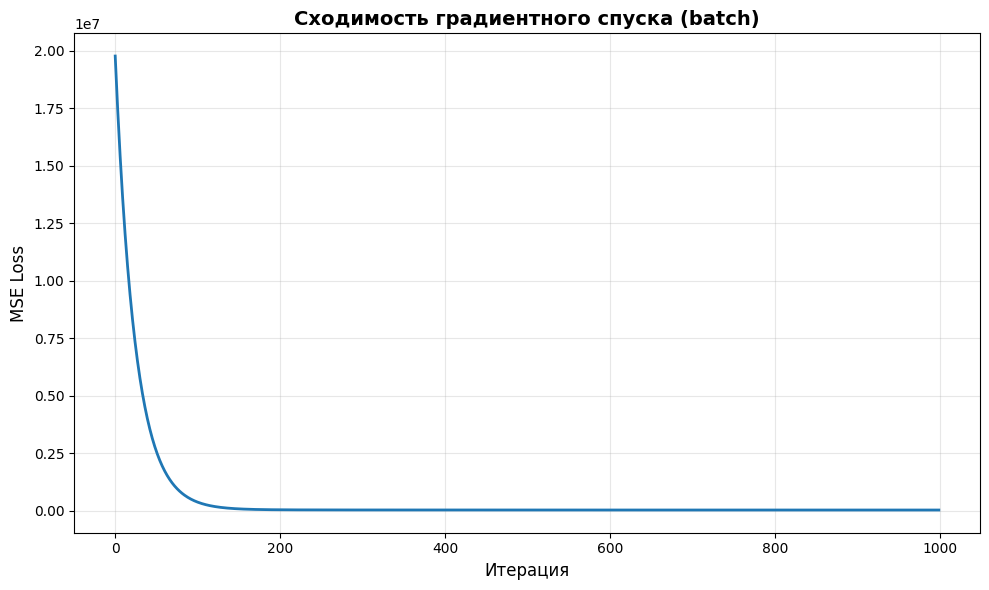

MSE: 41749.5194
MAE: 145.8232
MAPE: 0.0337
R²: 0.9507
Bias модели: 4330.325107905956, веса модели: [ 670.07825796  209.38401113 -185.78031286  351.72233668  203.47247623]


In [ ]:
model = GradientDescent(lr=0.01, n_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.plot_history()
model.print_metrics(y_test, y_pred)

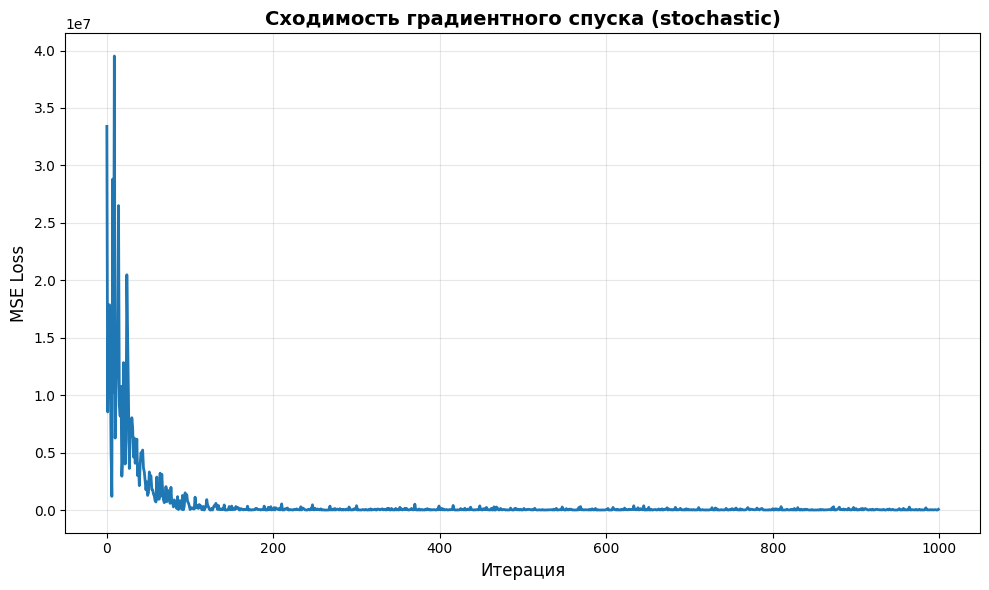

MSE: 38878.2315
MAE: 147.0761
MAPE: 0.0333
R²: 0.9541
Bias модели: 4299.659198475639, веса модели: [ 647.52847354  220.44896546 -139.3659932   351.56127404   -2.25061489
  206.11549939]


In [ ]:
model = GradientDescent(lr=0.01, n_iter=1000, modification='stochastic')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.plot_history()
model.print_metrics(y_test, y_pred)

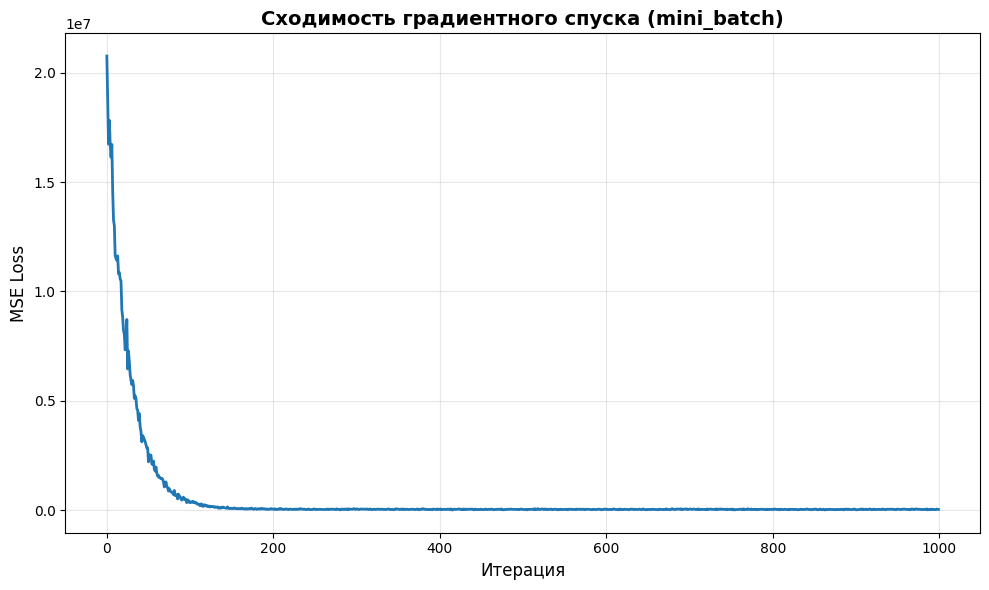

MSE: 41924.7093
MAE: 145.9135
MAPE: 0.0336
R²: 0.9505
Bias модели: 4326.311465352306, веса модели: [ 674.83246327  202.03107651 -160.62945801  365.530016     21.86030046
  182.49989729]


In [ ]:
model = GradientDescent(lr=0.01, n_iter=1000, modification='mini_batch')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.plot_history()
model.print_metrics(y_test, y_pred)

**Вывод:** В ходе экспериментов установлено, что градиентный спуск впринципе способен превзойти аналитическое решение МНК. По результатом эксперимента необходимо отметить следующее, что благодря случайной природе стохастический градиентный спуск показал наилучший результат, mini_batch показал результат на уровне с классичкесим градиентным спуском.

Классический градиентный спуск — хорошо подходит для небольшого набора данных; даёт стабильные, но медленные обновления параметров.

Мини-батчевый градиентный спуск — оптимальный выбор для средних и больших датасетов; ускоряет обучение, сглаживает шум стохастического метода.

Для нашей задачи будет вполне достаточно классического градиентного спуска. В следующем задании будем использовать именно этот метод, так как он стабилен и можно объективно оценить влияние регуляризации.

## Задание 6

А что, если бы мы не стали удалять никакие признаки, а просто сразу применили бы **регуляризацию**? Попробуйте в рамках этого задания:
* Взять данные **без удаления мультиколлинеарных признаков** и обучить на них лучший градиентный метод из предыдущих заданий, пока **без регуляризации**. Посмотрите, как ведут себя метрики на тренировочном и тестовом наборе, а также какие веса у модели.
* Взять данные **без удаления мультиколлинеарных признаков** и обучить на них лучший градиентный метод из предыдущих заданий, **с L1- и L2-регуляризацией** по отдельности. Сравните метрики и веса с предыдущим вариантом, а также с полученными результатами в 4 и 5 заданиях.
* Что лучше: обучиться на всех данных с регуляризацией или превентивно устранять мультиколлинеарность? Для самой наилучшей модели определите, какие признаки наиболее важны при прогнозировании. Отразите итоговые рекомендации в выводе.

**L1- и L2-регуляризация реализованы в классе `GradientDescent`**

In [ ]:
X = df.drop('extr_per_day', axis=1)
y = df['extr_per_day']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # разделение на train и test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Для дальнейшего анализа будем использовать классический градиентный спуск, так как он стабильнее.

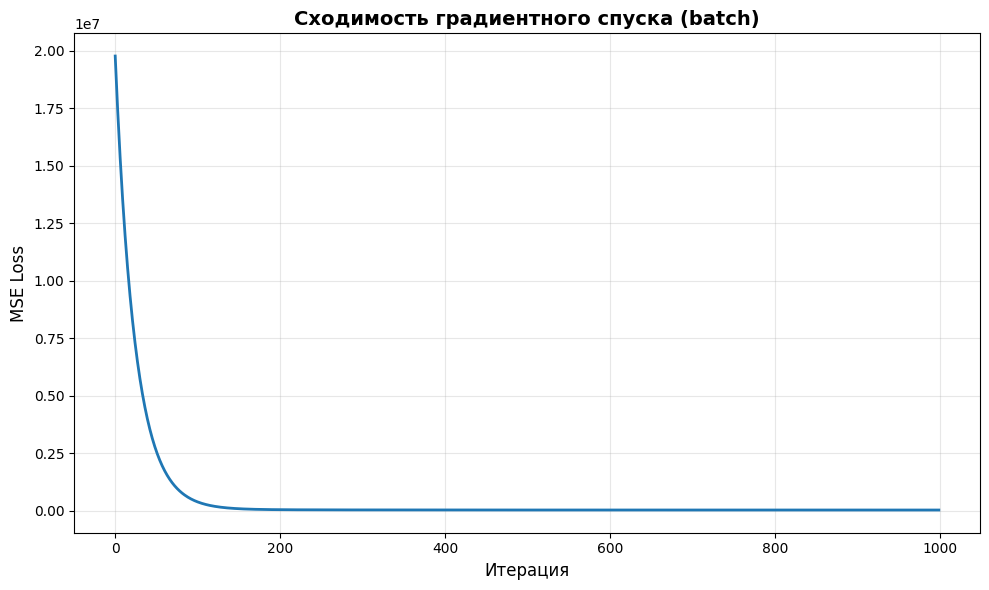

MSE: 43260.9014
MAE: 148.2751
MAPE: 0.0342
R²: 0.9489
Bias модели: 4330.325107905956, веса модели: [ 677.82496286  201.62141546 -157.75196458  363.20960391   23.59499438
  175.04629749]


In [ ]:
model = GradientDescent(lr=0.01, n_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.plot_history()
model.print_metrics(y_test, y_pred)

С L1-регуляризацией

In [ ]:
model = GradientDescent(lr=0.01, n_iter=1000, penalty='L1', alpha = 100)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.print_metrics(y_test, y_pred)

MSE: 65271.2775
MAE: 184.8142
MAPE: 0.0438
R²: 0.9229
Bias модели: 4330.325107905956, веса модели: [698.33384041 138.26659359  -1.61760322 359.75482056 120.12769075
  14.96875277]


С L2-регуляризацией

In [ ]:
model = GradientDescent(lr=0.01, n_iter=1000, penalty='L2', alpha = 0.1)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.print_metrics(y_test, y_pred)

MSE: 53669.0032
MAE: 173.6555
MAPE: 0.0402
R²: 0.9366
Bias модели: 4330.325107905956, веса модели: [ 546.54217242  244.41232352 -144.51656895  328.02436537   91.5210332
  156.1692297 ]


**Вывод:** В ходе экспериментов были рассмотрены четыре варианта модели: базовая линейная регрессия без регуляризации, модель с удалением признака, а также версии с L1- и L2-регуляризацией. Чтобы явно увидеть влияние регуляризации, коэффициенты α были намеренно увеличены, поскольку при малых значениях модель практически не менялась, а её качество оставалось идентичным базовой версии.

Результаты показали, что наилучшее качество достигается без регуляризации (R² = 0.9489). Удаление признака `organic_carbon` также не изменило метрики, что подтверждает его низкую полезность для прогноза. L1-регуляризация при увеличенных α привела к сильному ухудшению качества из-за подавления весов информативных признаков. L2-регуляризация также ухудшила модель, хотя и сгладила веса. Это указывает, что мультиколлинеарность не создаёт проблем переобучения, и регуляризация в данном случае работает скорее во вред.

Таким образом, в данной задаче предпочтительно не применять регуляризацию, а лишь при необходимости убирать слабоинформативные признаки. Наиболее важными для прогноза в лучшей модели остаются признаки с крупнейшими по абсолютной величине коэффициентами: porosity, brittleness, vitrinite_reflectance, а также permeability.

## Задание 7*

Попробуйте добавить еще больше эффективных модификаций и проверить их экспериментально:
* Реализуйте вручную алгоритм RMSProp (можете вспомнить AdaGrad и модифицировать его).
* Добавьте в него механизм ранней остановки через флаг в аргументе функции. Задайте опциональные гиперпараметры количества итераций без улучшения и пороговую разность значений ошибки на соседних итерациях.
* Поэкспериментируйте с гиперпараметрами и постарайтесь получить еще большее качество. Запишите наблюдения в выводе.

> **Справка по адаптивным градиентным методам:**

* $g_t = \nabla_{\theta} L(\theta_t)$ — градиент функции потерь
* $\varepsilon$ — малая константа для численной стабильности
* $\beta$ — коэффициент сглаживания


**Adagrad:** шаг обучения уменьшается для параметров с большими градиентами.

$$
G_t = G_{t-1} + g_t \odot g_t
$$

$$
\theta_{t+1} = \theta_t
\frac{\eta}{\sqrt{G_t} + \varepsilon}
\odot
g_t
$$


**RMSprop:** исправляет затухание шага в Adagrad за счет экспоненциального усреднения.

$$
v_t = \beta v_{t-1} + (1 - \beta), g_t \odot g_t
$$

$$
\theta_{t+1} = \theta_t
\frac{\eta}{\sqrt{v_t} + \varepsilon}
\odot
g_t
$$


**Алгоритм RMSProp реализован в классе `GradientDescent`**

Ранняя остановка: улучшение < eps на итерации 341


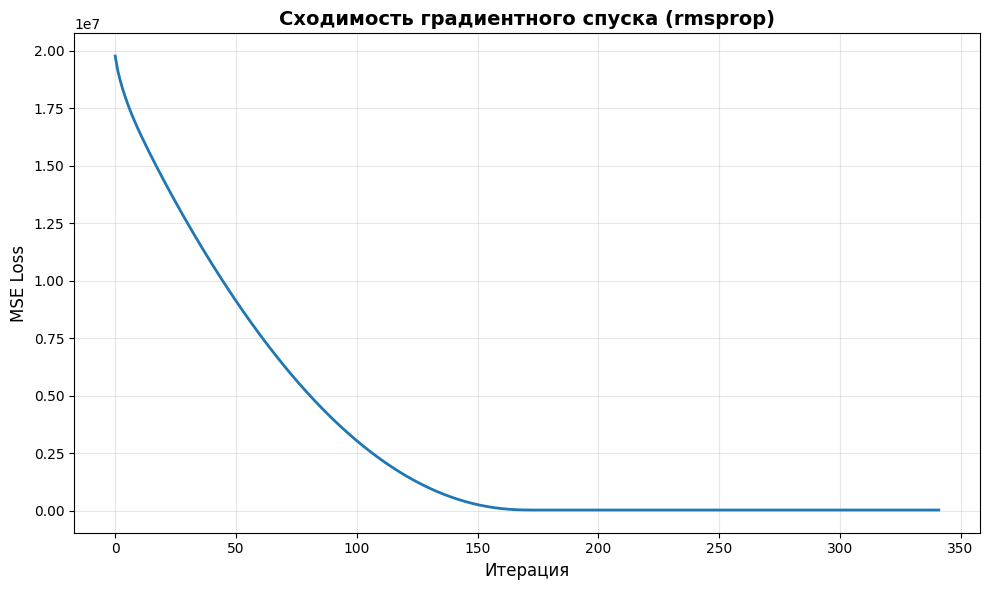

MSE: 37959.2698
MAE: 143.0544
MAPE: 0.0324
R²: 0.9551
Bias модели: 4317.325115198751, веса модели: [ 672.19114984  187.02195875 -164.36500279  368.21688112  -13.99781182
  208.86058172]


In [ ]:
model = GradientDescent(
    lr = 26,
    n_iter=1000,
    modification='rmsprop',
    beta=0.6,
    eps=1e-8,
    early_stopping=True,
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model.plot_history()
model.print_metrics(y_test, y_pred)

**Вывод:** По итогу экспериментов с гиперпараметрами удалось подобрать MSE =  37959.2698.